# 03 · Modelo global con LightGBM

Un solo modelo aprende de las 1,429 series a la vez (`mlforecast` + LightGBM):

- **Objetivo Tweedie**, adecuado para conteos con muchos ceros.
- **Autorregresivas:** lags 7/14/28 y medias móviles sobre esos lags.
- **Calendario:** día de la semana, día del mes, mes, SNAP, tipo y nombre de evento, días
  hasta el próximo evento.
- **Precio:** nivel, precio relativo a la historia del SKU y a su departamento, cambio en 7 días.
- El horizonte de 28 días se pronostica de forma **recursiva**.

Mismo protocolo que los baselines: 3 ventanas de evaluación de 28 días con
reentrenamiento. Las decisiones de modelado se tomaron en 3 ventanas *anteriores* (de
calibración), que no se reportan aquí.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.models import backtest as bt
from src.utils import plotting as pl

pl.use_style()
MODEL = "LightGBM"
wr = pd.read_parquet(config.METRICS_WRMSSE).query("split == 'eval'")
seg = pd.read_parquet(config.METRICS_SEGMENT).query("split == 'eval'")
cov = pd.read_parquet(config.METRICS_COVERAGE)
ablation = pd.read_parquet(config.ABLATION)
importance = pd.read_parquet(config.FEATURE_IMPORTANCE)

## 1. WRMSSE contra los baselines

In [2]:
by_window = wr[wr["level"] == "WRMSSE"].pivot(index="cutoff", columns="model", values="value")
by_window.index = by_window.index.strftime("%Y-%m-%d")
by_window.loc["promedio"] = by_window.mean()
order = by_window.loc["promedio"].sort_values().index
by_window[order].round(3)

model,LightGBM,AutoETS,SeasonalNaive,AutoARIMA,MediaMovil28,Naive
cutoff,,,,,,
2016-02-28,0.529,0.638,0.779,0.890,0.989,1.700
2016-03-27,0.511,0.578,0.879,0.870,0.974,1.263
2016-04-24,0.544,0.609,0.699,0.845,0.971,1.479
promedio,0.528,0.608,0.785,0.869,0.978,1.481


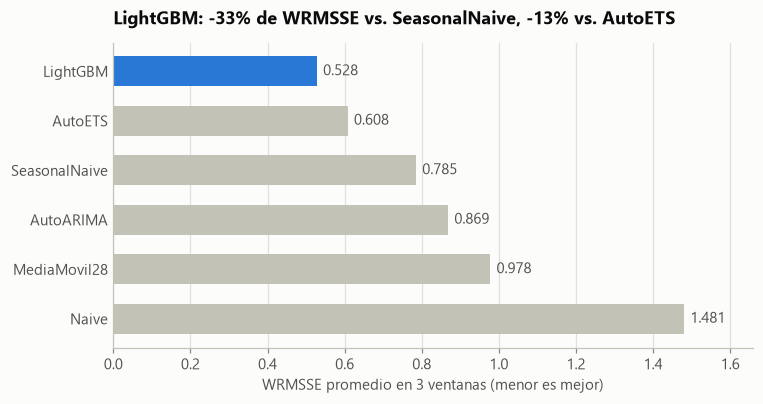

LightGBM gana en las 3 ventanas contra: AutoARIMA, AutoETS, MediaMovil28, Naive, SeasonalNaive


In [3]:
mean_wr = by_window.loc["promedio", order]
best_baseline = mean_wr.drop(MODEL).idxmin()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
colors = [pl.BLUE if m == MODEL else pl.AXIS for m in mean_wr.index[::-1]]
bars = ax.barh(mean_wr.index[::-1], mean_wr[::-1], height=0.6, color=colors)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in mean_wr[::-1]], padding=4, color=pl.INK_SECONDARY)
ax.set_title(
    f"LightGBM: {mean_wr[MODEL] / mean_wr['SeasonalNaive'] - 1:+.0%} de WRMSSE vs. SeasonalNaive, "
    f"{mean_wr[MODEL] / mean_wr[best_baseline] - 1:+.0%} vs. {best_baseline}"
)
ax.set_xlabel("WRMSSE promedio en 3 ventanas (menor es mejor)")
ax.set_xlim(0, mean_wr.max() * 1.12)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
pl.save(fig, "11_wrmsse_modelos")
plt.show()

wins = (by_window.drop("promedio")[MODEL].to_numpy()[:, None] < by_window.drop("promedio").drop(columns=MODEL)).all()
print("LightGBM gana en las 3 ventanas contra:", ", ".join(wins[wins].index))

LightGBM tiene el menor WRMSSE en **las tres ventanas** y contra todos los baselines: 33%
menos que SeasonalNaive (el criterio de éxito del proyecto) y 13% menos que AutoETS, que
es la referencia exigente.

## 2. ¿Dónde gana y dónde pierde?

Comparación de WAPE (nivel SKU-día) contra el **mejor baseline de cada segmento**, no
contra uno fijo.

In [4]:
def versus_best(grouping: str) -> pd.DataFrame:
    tab = seg[seg["grouping"] == grouping].pivot(index="group", columns="model", values="wape")
    base = tab.drop(columns=MODEL)
    out = pd.DataFrame(
        {
            "n_skus": seg[seg["grouping"] == grouping].groupby("group")["n_skus"].first(),
            "wape_lightgbm": tab[MODEL],
            "mejor_baseline": base.idxmin(axis=1),
            "wape_baseline": base.min(axis=1),
        }
    )
    out["diferencia"] = out["wape_lightgbm"] / out["wape_baseline"] - 1
    return out


vs_segment = versus_best("segment")
vs_pattern = versus_best("pattern")
vs_segment.round(3)

,n_skus,wape_lightgbm,mejor_baseline,wape_baseline,diferencia
group,,,,,
AX,306,0.501,AutoETS,0.516,-0.030
AY,245,0.575,AutoETS,0.611,-0.058
AZ,52,0.686,AutoARIMA,0.681,0.007
BX,85,0.862,AutoETS,0.855,0.009
BY,302,0.970,AutoETS,0.949,0.022
BZ,71,0.842,AutoETS,0.815,0.033
CX,10,1.069,AutoETS,1.023,0.045
CY,168,1.253,AutoETS,1.134,0.105
CZ,190,1.114,AutoARIMA,0.959,0.161


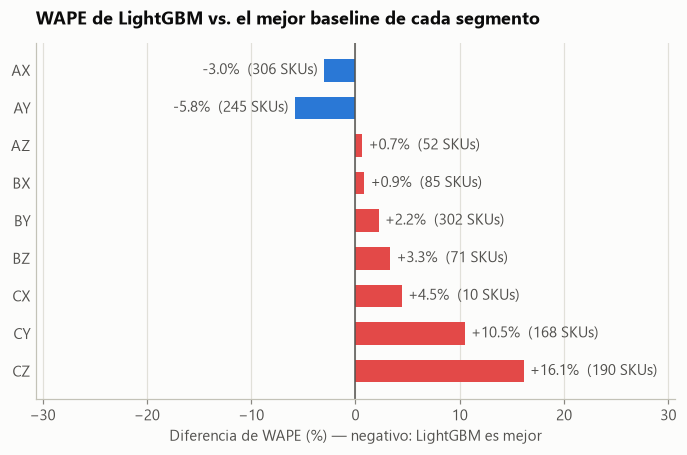

,n_skus,wape_lightgbm,mejor_baseline,wape_baseline,diferencia
group,,,,,
errática,37,0.607,MediaMovil28,0.635,-0.044
intermitente,925,0.807,AutoETS,0.789,0.023
irregular,254,0.978,AutoETS,0.936,0.045
suave,213,0.443,AutoETS,0.465,-0.047


In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
d = vs_segment["diferencia"][::-1] * 100
colors = [pl.BLUE if v < 0 else pl.RED for v in d]
bars = ax.barh(d.index, d.to_numpy(), height=0.6, color=colors)
labels = [f"{v:+.1f}%  ({n} SKUs)" for v, n in zip(d, vs_segment["n_skus"][::-1], strict=True)]
ax.bar_label(bars, labels=labels, padding=4, color=pl.INK_SECONDARY)
ax.axvline(0, color=pl.INK_SECONDARY, linewidth=1)
ax.set_title("WAPE de LightGBM vs. el mejor baseline de cada segmento")
ax.set_xlabel("Diferencia de WAPE (%) — negativo: LightGBM es mejor")
span = max(abs(d.min()), abs(d.max())) * 1.9
ax.set_xlim(-span, span)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
pl.save(fig, "12_lightgbm_vs_baseline_segmento")
plt.show()

vs_pattern.round(3)

In [6]:
bias = seg[seg["grouping"].isin(["total", "abc"])].pivot(index="group", columns="model", values="bias")
bias.loc[["Total", "A", "B", "C"], order].round(3)

model,LightGBM,AutoETS,SeasonalNaive,AutoARIMA,MediaMovil28,Naive
group,,,,,,
Total,0.004,-0.030,-0.042,-0.022,-0.040,0.234
A,-0.029,-0.021,-0.033,-0.005,-0.029,0.247
B,0.031,-0.051,-0.058,-0.048,-0.059,0.216
C,0.205,-0.069,-0.089,-0.100,-0.093,0.166


El resultado es menos uniforme de lo que sugiere el WRMSSE:

- **Gana donde hay volumen:** AX (−3%) y AY (−6%), que suman tres cuartas partes del
  ingreso, y en los patrones suave y errático (−4 a −5%).
- **Empata** en AZ y BX.
- **Pierde en la cola:** de +2% en BY hasta +16% en CZ. En demanda intermitente e irregular
  un promedio simple es mejor estimador a nivel SKU.
- **Sesgo:** casi nulo en el total (+0.4%), pero el modelo sobre-pronostica la clase C en
  ~20%. Con ventas cercanas a cero, la media que predice un objetivo Tweedie queda por
  encima de la mayoría de los días.

¿Por qué entonces el WRMSSE mejora 13% si el WAPE total empata con AutoETS (0.667)?
Porque el WRMSSE pondera por ingreso y promedia tres niveles de agregación: la ventaja del
modelo está en los SKUs que más venden y en los niveles total y departamento, donde sus
errores se compensan mejor.

**Lectura de negocio:** ML para las clases A y B alta; para la clase C, una regla simple es
igual de buena y más barata de mantener.

## 3. Error a lo largo del horizonte

El pronóstico es recursivo: los lags de los días lejanos son, en parte, predicciones.
¿Se degrada hacia el día 28?

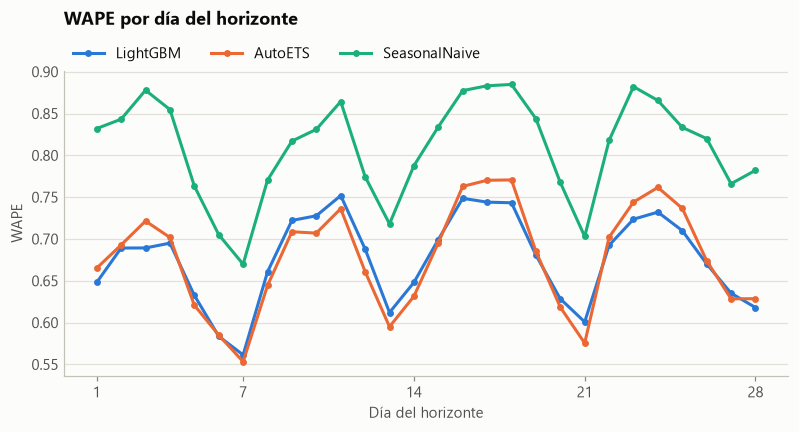

,LightGBM,AutoETS,SeasonalNaive
semana 1,0.643,0.649,0.792
semana 2,0.687,0.669,0.795
semana 3,0.692,0.697,0.828
semana 4,0.683,0.696,0.824


In [7]:
cv = bt.load_cv()
cv = cv[cv["cutoff"].isin(sorted(cv["cutoff"].unique())[-config.N_WINDOWS :])]
cv["step"] = (cv["ds"] - cv["cutoff"]).dt.days
models = [MODEL, "AutoETS", "SeasonalNaive"]
by_step = pd.DataFrame(
    {m: (cv[m] - cv["y"]).abs().groupby(cv["step"]).sum() / cv.groupby("step")["y"].sum() for m in models}
)
weekly = by_step.groupby((by_step.index - 1) // 7 + 1).mean()
weekly.index = [f"semana {i}" for i in weekly.index]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for m, color in zip(models, pl.CATEGORICAL, strict=False):
    ax.plot(by_step.index, by_step[m], color=color, label=m, marker="o", markersize=3.5)
ax.set_title("WAPE por día del horizonte", pad=30)
ax.set_xlabel("Día del horizonte")
ax.set_ylabel("WAPE")
ax.set_xticks([1, 7, 14, 21, 28])
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=3, borderaxespad=0.2)
pl.save(fig, "13_error_por_horizonte")
plt.show()

weekly.round(3)

El error sube ~7% después de la primera semana y luego se estabiliza: la recursión no se
degrada de forma acumulativa hacia el día 28. El diente de sierra es el ciclo semanal (los
fines de semana tienen más volumen y menor error relativo).

## 4. Ablaciones (en ventanas de calibración)

Qué aporta cada grupo de variables. Se evalúa en las 3 ventanas **previas** al periodo de
evaluación, para que elegir la configuración no contamine los resultados reportados.

In [8]:
ablation.drop(columns="seconds").round(4)

,variant,wrmsse,wape,bias,wrmsse_vs_base
0,base,0.5295,0.7163,-0.0035,0.0000
1,con item_id,0.5591,0.7252,0.0478,0.0558
2,sin precio,0.5312,0.7264,0.0157,0.0031
3,sin calendario,0.5610,0.7199,-0.0048,0.0595
4,objetivo Poisson,0.5342,0.7207,0.0035,0.0088


- **`item_id` como categórica empeora el modelo** (+5.6% de WRMSSE y un sesgo de +5%): con
  1,429 niveles, el modelo memoriza el SKU en vez de generalizar. Por eso quedó fuera; el
  nivel de cada SKU ya lo aportan sus medias móviles.
- **El calendario aporta** (+6% sin él): SNAP, eventos y la cuenta regresiva al evento.
- **El precio aporta poco en WRMSSE** (+0.3%) aunque algo más en WAPE: el efecto de un
  descuento es fuerte pero ocurre en ~4% de los días.
- **Tweedie vs. Poisson:** diferencia menor a 1%, a favor de Tweedie.

Nota de honestidad: la mejora de quitar `item_id` se observó en calibración. En las
ventanas de evaluación el WRMSSE quedó prácticamente igual (0.528 vs 0.530) y el sesgo
bajó de +2.9% a +0.4%. La decisión se mantuvo porque se tomó sin mirar la evaluación.

## 5. Importancia de variables

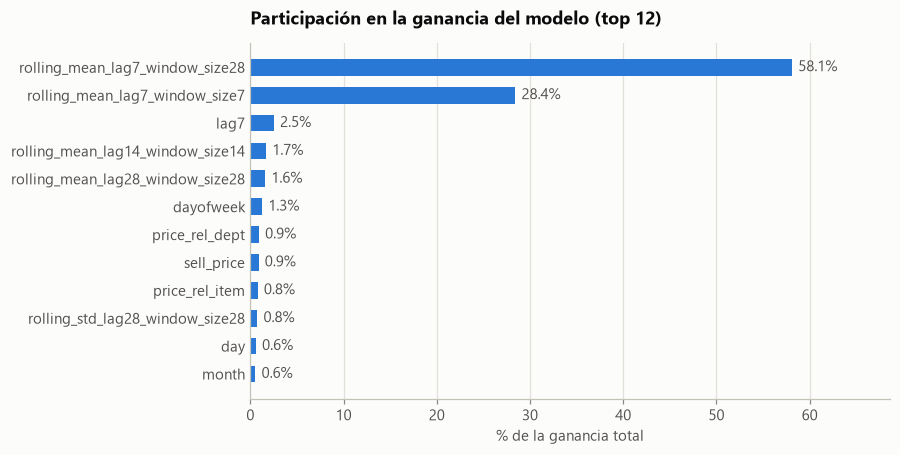

In [9]:
top = importance.head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.barh(top["feature"], top["gain_share"] * 100, height=0.6, color=pl.BLUE)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in top["gain_share"]], padding=4, color=pl.INK_SECONDARY)
ax.set_title("Participación en la ganancia del modelo (top 12)")
ax.set_xlabel("% de la ganancia total")
ax.set_xlim(0, top["gain_share"].max() * 118)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
pl.save(fig, "14_importancia_variables")
plt.show()

Las medias móviles de 7 y 28 días concentran más del 85% de la ganancia: el modelo es, en
esencia, un promedio inteligente que se corrige con el día de la semana, el calendario y el
precio. Es coherente con lo visto en los baselines: en esta demanda, el nivel reciente es
casi toda la señal.

## 6. Intervalos de predicción

Intervalos conformales por SKU: los márgenes son cuantiles empíricos de los errores fuera
de muestra. Para medir la cobertura honestamente, los márgenes se calibran con las 3
ventanas de calibración y se evalúan en las 3 de evaluación.

In [10]:
coverage = cov[cov["grouping"].isin(["total", "abc", "pattern"])].pivot(
    index=["grouping", "group"], columns="level", values="coverage"
)
coverage.columns = [f"cobertura {c}%" for c in coverage.columns]
coverage.round(3)

cobertura 80%  cobertura 95%
grouping group                                     
abc      A                     0.755          0.900
         B                     0.745          0.897
         C                     0.691          0.856
pattern  errática              0.746          0.900
         intermitente          0.725          0.879
         irregular             0.733          0.879
         suave                 0.782          0.930
total    Total                 0.736          0.887

**Los intervalos quedan cortos:** 74% de cobertura para el intervalo de 80% y 89% para el
de 95%, unos 6 puntos por debajo de lo nominal (el objetivo era ±5). Solo la demanda suave
se acerca (78% / 93%).

Causas probables: cada SKU se calibra con apenas 3 ventanas (84 errores), la demanda no es
estacionaria (viene creciendo) y un mismo margen se usa para los 28 días del horizonte.
El pronóstico final usa las 6 ventanas, lo que debería acercarlo, pero eso no se puede
verificar con los datos disponibles.

Consecuencia práctica: los intervalos sirven como referencia visual, pero **el safety stock
no se toma de ellos**: se valida directamente en la simulación del notebook 04.

## 7. Ejemplos

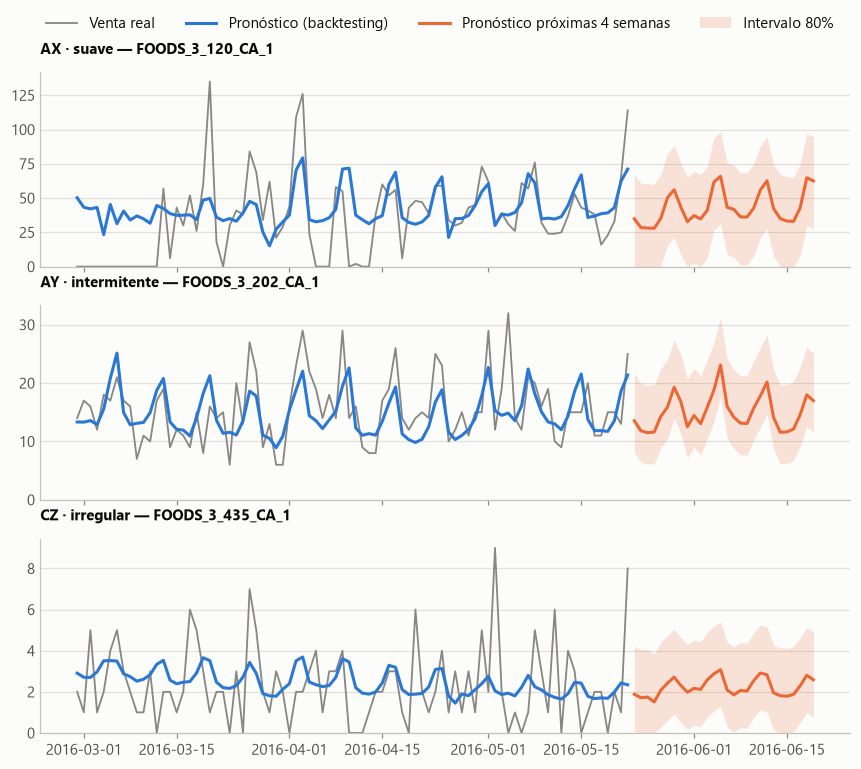

In [11]:
classes = pd.read_parquet(config.ABC_XYZ).set_index("unique_id")
sales = pd.read_parquet(config.SALES_LONG, columns=["unique_id", "ds", "y"])
future = pd.read_parquet(config.FORECAST_FUTURE)
# El SKU de mayor ingreso de tres perfiles distintos.
picks = {
    name: classes[mask].sort_values("revenue", ascending=False).index[0]
    for name, mask in {
        "AX · suave": (classes["segment"] == "AX") & (classes["pattern"] == "suave"),
        "AY · intermitente": (classes["segment"] == "AY") & (classes["pattern"] == "intermitente"),
        "CZ · irregular": (classes["segment"] == "CZ") & (classes["pattern"] == "irregular"),
    }.items()
    if mask.any()
}

fig, axes = plt.subplots(len(picks), 1, figsize=(9.5, 2.6 * len(picks)), sharex=True)
for ax, (name, uid) in zip(np.atleast_1d(axes), picks.items(), strict=True):
    hist = sales[sales["unique_id"] == uid].tail(config.N_WINDOWS * config.HORIZON)
    back = cv[cv["unique_id"] == uid]
    fut = future[future["unique_id"] == uid]
    ax.plot(hist["ds"], hist["y"], color=pl.MUTED, linewidth=1.2, label="Venta real")
    ax.plot(back["ds"], back[MODEL], color=pl.BLUE, label="Pronóstico (backtesting)")
    ax.plot(fut["ds"], fut[MODEL], color=pl.ORANGE, label="Pronóstico próximas 4 semanas")
    ax.fill_between(fut["ds"], fut[f"{MODEL}-lo-80"], fut[f"{MODEL}-hi-80"], color=pl.ORANGE,
                    alpha=0.18, linewidth=0, label="Intervalo 80%")
    ax.set_title(f"{name} — {uid}", fontsize=10)
    ax.set_ylim(0)
np.atleast_1d(axes)[0].legend(loc="lower left", bbox_to_anchor=(0, 1.18), ncols=4, borderaxespad=0)
pl.save(fig, "15_ejemplos_pronostico")
plt.show()

## Resumen

| Hallazgo | Implicación |
| --- | --- |
| WRMSSE 33% menor que SeasonalNaive y 13% menor que AutoETS, en las 3 ventanas | Criterio de éxito cumplido |
| Gana en AX/AY y demanda suave; pierde en la clase C | Segmentar: ML donde hay volumen, regla simple en la cola |
| Sobre-pronostica ~20% la clase C | Explica el exceso de inventario en C que se verá en la simulación |
| La recursión no se degrada hacia el día 28 | El horizonte de 4 semanas es utilizable completo |
| Intervalos ~6 puntos por debajo de su cobertura nominal | El safety stock se valida por simulación, no con los intervalos |